In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.layers import LSTM,TimeDistributed,Dense,RepeatVector
from keras.models import Model

I0000 00:00:1785252827.456311   29463 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set seeds

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
#Configuration 

features = ['visitors','avgDuration','weekday','hour_sin','hour_cos']
train_ratio = 0.8
window_size = 24
step = 1
THRESHOLD_PCTL = 95

In [4]:
#Load final data
data = pd.read_csv('final_data.csv',index_col=False)

In [5]:
def make_windows(series: np.ndarray, window: int, step: int) -> np.ndarray:
    windows = [series[s: s+window] for s in range (0,len(series)-window+1,step)]
    arr =  np.array(windows, dtype=np.float32)
    return arr

In [6]:
def sensor_preparation(sensor_data: pd.DataFrame):
    data = sensor_data[features].values

    if len(data) < window_size+1:
        return None

    split = int(len(data)*train_ratio)
    scaler = StandardScaler()
    train_data = scaler.fit_transform(data[:split])
    test_data = scaler.transform(data[split:])

    X_train = make_windows(train_data,window_size,step)
    X_test = make_windows(test_data,window_size,step) 
    
    ts      = sensor_data["timestamp"].values
    test_ts = ts[split + window_size - 1: split + window_size - 1 + len(X_test)]
    return X_train, X_test, test_ts


In [7]:
#define model

def build_lstm_autoencoder(seq_len: int, n_features:int) -> keras.Model:

    inputs = keras.Input(shape= (seq_len,n_features))

    #Encoder
    x = LSTM(64,return_sequences = True)(inputs)
    x = LSTM(32,return_sequences = False)(x)

    bottleneck = Dense(16,activation='relu')(x)

    #Decoder
    x = RepeatVector(seq_len)(bottleneck)
    x = LSTM(32,return_sequences = True)(x)
    x = LSTM(64,return_sequences = True)(x)

    outputs =TimeDistributed(Dense(n_features),name = 'output')(x)

    model = keras.models.Model(inputs,outputs)
    model.compile(optimizer= 'adam',
                 loss = 'mse')

    return model

In [8]:
#Train model

def train_model(X_train: np.ndarray):
    n_features = X_train.shape[2]
    model = build_lstm_autoencoder(window_size,n_features)

    history = model.fit(
        X_train, X_train,
        epochs = 50,
        batch_size=32,
        validation_split=0.1,
        verbose = 1
    )

    return model, history
    

In [9]:
#Anamoly detection

def reconstruction_errors(model:Model, windows: np.ndarray)-> np.ndarray:
    pred = model.predict(windows,batch_size = 32)
    return np.mean((windows-pred) ** 2, axis = (1,2))

In [10]:
def detect_anomalies(model, X_train, X_test):
    train_err = reconstruction_errors(model, X_train)
    test_err  = reconstruction_errors(model, X_test)
    threshold = np.percentile(train_err, THRESHOLD_PCTL)
    anomalies = test_err > threshold
    return train_err, test_err, threshold, anomalies

In [11]:
def plot_results(name, ts, errors, threshold, anomalies, loss, ax1, ax2):
    ts = pd.to_datetime(ts)
    ax1.plot(ts, errors, label="error")
    ax1.axhline(threshold, linestyle="--", label="threshold",color='black')
    if anomalies.any():
        ax1.scatter(
            ts[anomalies],
            errors[anomalies],
            color = 'red',
            label='anomaly')
    ax1.set_title(f'Anamolies on Sensor {name}')
    ax1.legend()
    ax2.plot(loss)
    ax2.set_title("Loss")

In [14]:
def main():
    df = data
    sensor_id = df['SID'].value_counts().head(10)
    sensor_id = sensor_id.index.to_list()
    results = []

    fig, axes = plt.subplots(len(sensor_id), 2, figsize=(20, 40))

    for i, sid in enumerate(sensor_id):
        sensor_df = df[df["SID"] == sid]

        out = sensor_preparation(sensor_df)
        
        if out is None:
            continue
            
        X_train, X_test, test_ts = out

        model, history = train_model(X_train)
        train_loss = history.history['loss']
    
        train_err, test_err, threshold, anomalies = detect_anomalies(
            model, X_train, X_test
        )

        name = sensor_df["name"].iloc[0]

        if anomalies.sum() > 0:
            for ts, err in zip(test_ts[anomalies], test_err[anomalies]):
                results.append({
                    "SID": sid,
                    "name": name,
                    "timestamp": ts,
                    "error": err
                })

        plot_results(
            name,
            test_ts,
            test_err,
            threshold,
            anomalies,
            train_loss,
            axes[i, 0],
            axes[i, 1]
        )

    

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - loss: 1.0426 - val_loss: 0.6635
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.9654 - val_loss: 0.6600
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.9006 - val_loss: 0.6432
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8754 - val_loss: 0.6354
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8597 - val_loss: 0.6265
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.8436 - val_loss: 0.6137
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.8232 - val_loss: 0.5874
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.7875 - val_loss: 0.5426
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.7321 - val_loss: 0.4785
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6720 - val_loss: 0.4089
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6191 - val_loss: 0.3486
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5595 - val_loss: 0.2816


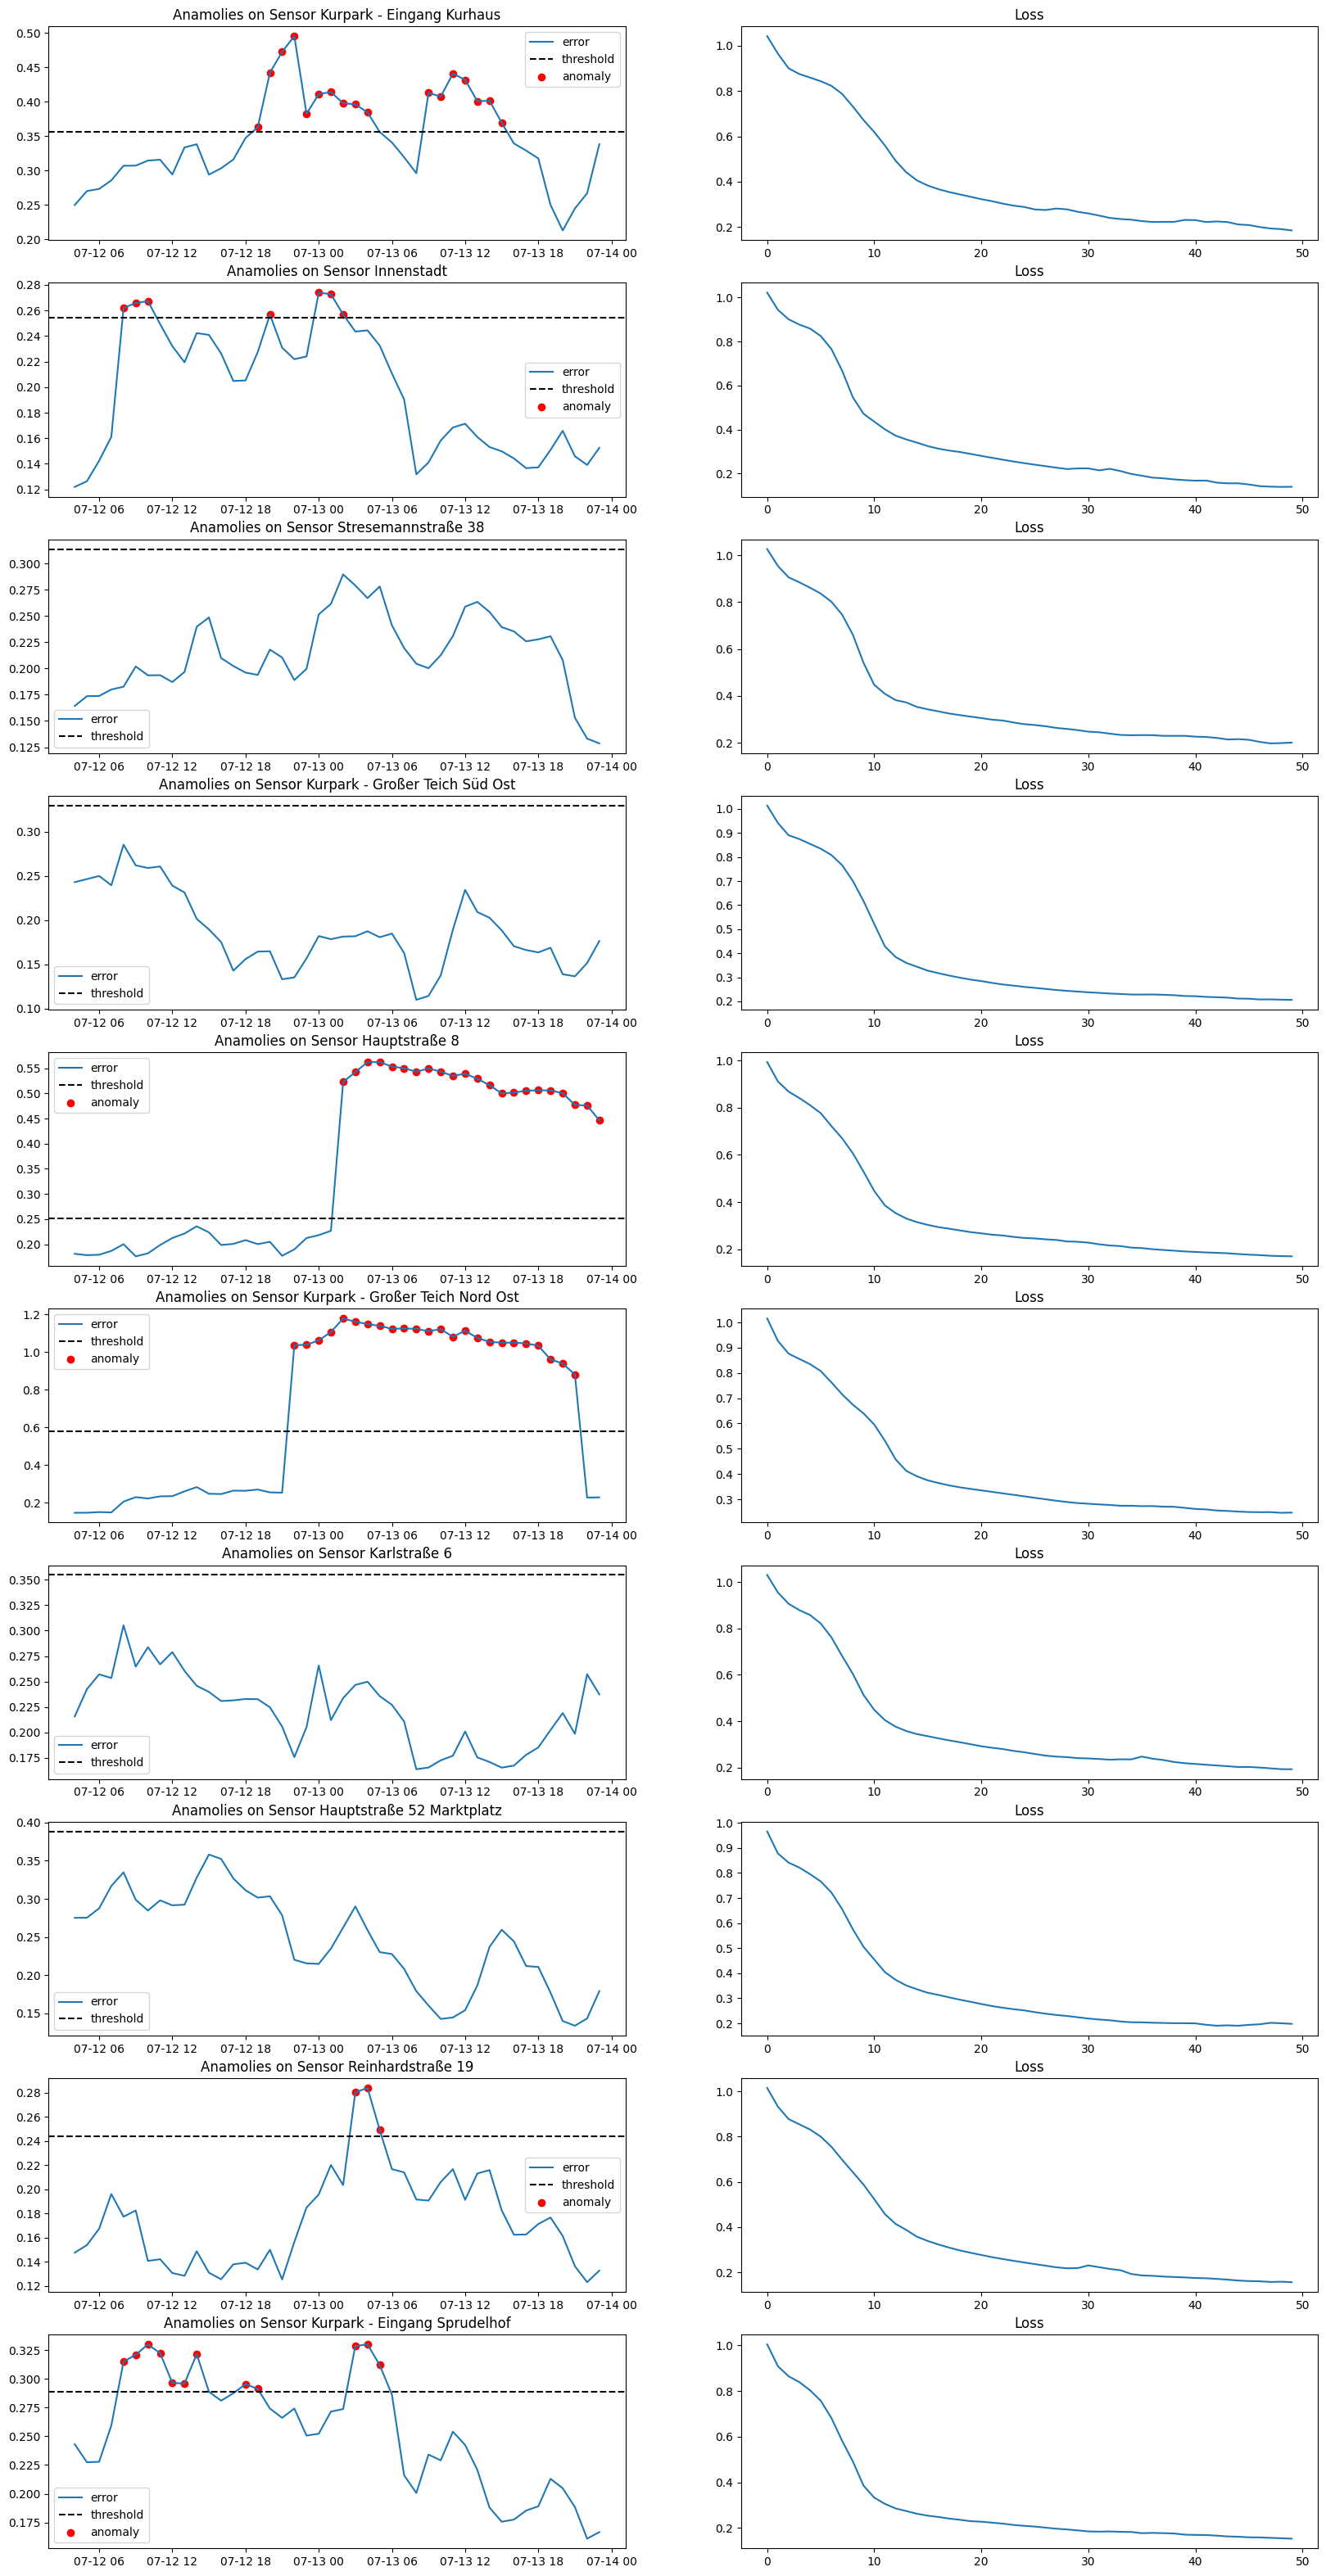

In [15]:
if __name__ == "__main__":
    main()